<a href="https://colab.research.google.com/github/djlakhani/spuco_BigML/blob/main/spuco_bigml_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spurious Correlations BigML Application Project

In [216]:
%%capture
%pip install spuco;

In [217]:
#imports

import pandas as pd
import numpy as np
import torch
from PIL import Image
from torch.utils.data import DataLoader

In [218]:
# loading datasets
# code below is from SpuCo Quickstart Notebook tutorials

from spuco.datasets import SpuCoMNIST, SpuriousFeatureDifficulty
import torchvision.transforms as T

# 5 superclasses, with 2 subclasses in each
classes = [[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]]
difficulty = SpuriousFeatureDifficulty.MAGNITUDE_LARGE

trainset = SpuCoMNIST(
    root="/data/mnist/",
    spurious_feature_difficulty=difficulty,
    spurious_correlation_strength=0.995,
    classes=classes,
    split="train"
)
trainset.initialize()

testset = SpuCoMNIST(
    root="/data/mnist/",
    spurious_feature_difficulty=difficulty,
    classes=classes,
    split="test"
)
testset.initialize()

The dataset above has been initialized using parameters from the SpuCo QuickStart Notebook Tutorials: https://github.com/BigML-CS-UCLA/SpuCo/blob/master/quickstart/spuco_mnist/spuco_mnist_cluster.ipynb.
For our classification task, we have five super classes. Class 0 consists of images of digits 0 and 1, class 1 consists of images of digits 2 and 3, class 2 consists of images of digits 4 and 5 and so on.

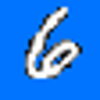

In [219]:
# displaying image from our dataset
# the background colors are the spurious feature
T.ToPILImage()(trainset[12][0]).resize((100,100))

The spurious feature in the dataset is the background color. In the training set each class has their own distinct background color. For instance, in class 0, digits 0 and 1 have background color red and in class 3, digits 6 and 7 have background color blue. Conversely, the testing set has no well-defined background colors per class. If we train a CNN model on the training dataset, the model may learn to rely on the background color to classify the images. This strategy will however fail to classify images correctly in the testing dataset.

## 1) Train a model using ERM

In [220]:
# dividing data into batches

train_loader = DataLoader(
    trainset,
    batch_size=64,
    shuffle=True
)

In [221]:
test_loader = DataLoader(
    testset,
    batch_size=64,
    shuffle=True
)

In [222]:
# saving linear layer of CNN
all_class = torch.randn(1, 784)
all_class_labels = torch.tensor(np.array([1]))

In [223]:
# a simple CNN model

import torch.nn as nn
import torch.nn.functional as F

class spucoCNN(nn.Module):
    def __init__(self, n_class):
        super().__init__()
        self.n_class = n_class

        self.conv1 = nn.Conv2d(3, 6, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(6, 12, kernel_size=3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(12, 16, kernel_size=3, stride=2, padding=1)

        self.classifier = nn.Linear(784, self.n_class)

        self.relu = nn.ReLU()

    def forward(self, x, save_linear=False):
        x1 = self.relu(self.conv1(x))
        x2 = self.relu(self.conv2(x1))
        x3 = self.relu(self.conv3(x2))
        x3 = torch.flatten(x3, start_dim=1)
        save_linear = x3.clone()
        classified = self.classifier(x3)

        return classified, save_linear

In [224]:
# writing a training loop
import numpy as np

spucoCNN_model = spucoCNN(n_class = 5)

# update weights
optimizer = torch.optim.AdamW(spucoCNN_model.parameters(), lr = 0.001)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = torch.nn.CrossEntropyLoss() # using Cross Entropy Loss for classification
spucoCNN_model = spucoCNN_model.to(device)

def train():

  num_epoch = 5

  for epoch in range(num_epoch):
    spucoCNN_model.train()
    for i, (inputs, labels) in enumerate(train_loader):
      optimizer.zero_grad()
      inputs = inputs.to(device)
      labels = labels.to(device)

      outputs = spucoCNN_model.forward(inputs)  # ouputs = logits, linear_layer
      predicted_labels = torch.argmax(outputs[0], axis=1)
      accuracy = np.mean(np.array(labels == predicted_labels))

      loss = criterion(outputs[0], labels)
      loss.backward()
      optimizer.step()

      if i % 100 == 0:
          print(f"epoch {epoch}, iter {i}, loss: {loss.item()}, accuracy: {accuracy}")


# training the model
train()

epoch 0, iter 0, loss: 1.6030274629592896, accuracy: 0.234375
epoch 0, iter 100, loss: 0.004069989081472158, accuracy: 1.0
epoch 0, iter 200, loss: 0.01055274996906519, accuracy: 1.0
epoch 0, iter 300, loss: 0.012603724375367165, accuracy: 1.0
epoch 0, iter 400, loss: 0.0072442409582436085, accuracy: 1.0
epoch 0, iter 500, loss: 0.12859228253364563, accuracy: 0.984375
epoch 0, iter 600, loss: 0.1357601135969162, accuracy: 0.984375
epoch 0, iter 700, loss: 0.024754762649536133, accuracy: 1.0
epoch 1, iter 0, loss: 0.005571048241108656, accuracy: 1.0
epoch 1, iter 100, loss: 0.09924358129501343, accuracy: 0.984375
epoch 1, iter 200, loss: 0.005967699456959963, accuracy: 1.0
epoch 1, iter 300, loss: 0.008701466023921967, accuracy: 1.0
epoch 1, iter 400, loss: 0.10894095152616501, accuracy: 0.984375
epoch 1, iter 500, loss: 0.0031021968461573124, accuracy: 1.0
epoch 1, iter 600, loss: 0.006638482678681612, accuracy: 1.0
epoch 1, iter 700, loss: 0.004905245266854763, accuracy: 1.0
epoch 2, 

In [225]:
# evaluating model performance before GDRO
def test():
  num_batches = 0
  acc_agg = 0
  spucoCNN_model.eval()
  for i, (inputs, labels) in enumerate(test_loader):
    inputs = inputs.to(device)
    labels = labels.to(device)

    outputs = spucoCNN_model.forward(inputs)  # ouputs = logits, linear_layer
    predicted_labels = torch.argmax(outputs[0], axis=1)
    accuracy = np.mean(np.array(labels == predicted_labels))

    if i % 50 == 0:
          print(f"iter {i}, accuracy: {accuracy}")
    num_batches = num_batches + 1
    acc_agg = acc_agg + accuracy

  print(f"final accuracy: {acc_agg / num_batches}")

test()

iter 0, accuracy: 0.234375
iter 50, accuracy: 0.265625
iter 100, accuracy: 0.203125
iter 150, accuracy: 0.234375
final accuracy: 0.20979299363057324


The massive discrepancy between the training accuracy and the final testing (~20%) accuracy indicates that our model is utilizing the spurious feature (background color) to make classifications.

## 2) Dimensionality reduction and clustering of CNN linear layer

In [226]:
# creating new trainset to accomodate subclass labels
trainset_subclass = []
for img, sup in trainset:
  trainset_subclass.append((img, sup, -1))
print(len(trainset_subclass))

48004


Now that the model is trained, we will pass in the training images through the model and save the values of the last linear layer of the model. The last linear layer is a 784 x 1 vector that encodes information about the features of the image. These vectors can be used to distinguish between the two digits present in a single class, i.e., obtain the subclass labels.

In [227]:
# saving the linear layer for each image
trainset_subclass_loader = DataLoader(
    trainset_subclass,
    batch_size=64,
    shuffle=False
)

#reset globals before calling again
def separate_classes():
  global all_class, all_class_labels
  for i, (inputs, labels, subclass_labels) in enumerate(trainset_subclass_loader):
    inputs = inputs.to(device)
    labels = labels.to(device)
    # subclass_labels = -1

    outputs = spucoCNN_model.forward(inputs)  # ouputs = logits, linear_layer
    all_class = torch.cat((all_class, outputs[1]), 0)
    all_class_labels = torch.cat((all_class_labels, labels), 0)

separate_classes()

In [228]:
# removing first rand entry of all_class and all_class_labels

all_class = all_class[1:]
all_class_labels = all_class_labels[1:]

print(all_class.shape)
print(all_class_labels.shape)

torch.Size([48004, 784])
torch.Size([48004])


In [229]:
# ensuring order is preserved
idx = 0
for (img, sup, sub) in trainset_subclass:
  if (all_class_labels[idx] != sup):
    print("order not maintained")
    break
  idx = idx + 1

Before clustering the vectors class, we will reduce the dimensions of the dataset from 784 to 2. This will remove any redundant features in the vectors and allow us to plot the clusters obtained. In the George tutorial, the UMAP reduction technique was recommended and has been implemented below.

In [237]:
# reducing dimensions 784 -> 2 before clustering
# umap recommended in George demo

import umap
reducer = umap.UMAP()
embedding = reducer.fit_transform(all_class.detach().numpy())
embedding.shape

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(48004, 2)

In [238]:
# seperating all the super-classes for classification
class0 = embedding[all_class_labels == 0]
class1 = embedding[all_class_labels == 1]
class2 = embedding[all_class_labels == 2]
class3 = embedding[all_class_labels == 3]
class4 = embedding[all_class_labels == 4]

In [239]:
print(class0.shape)
print(class1.shape)
print(class2.shape)
print(class3.shape)
print(class4.shape)

(10133, 2)
(9672, 2)
(9011, 2)
(9747, 2)
(9441, 2)


The next step is to cluster the 2-dimensional vectors per superclass. The purpose of this is to distinguish the two digits in each subclass. I have chosen the K-Means algorithm for clustering. The output of the K-Means algorithm, i.e. the labels for the clustering of each superclass, are the subclass labels for each superclass.

In [240]:
# clustering class 0 superclass [0, 1] into two subclasses
from sklearn.cluster import KMeans
kmeans0 = KMeans(n_clusters=2, random_state=0, n_init="auto")
kmeans0.fit(class0)
labels0 = kmeans0.labels_

Text(0.5, 1.0, 'Superclass 0 [0, 1] Clusters')

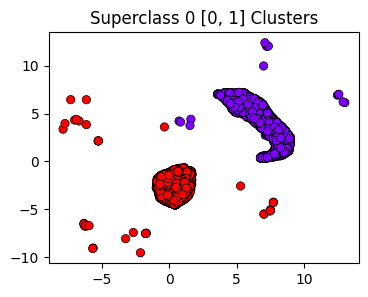

In [241]:
# plotting class0 clusters
import matplotlib.pyplot as plt
plt.figure(figsize=(4, 3))
plt.scatter(class0[:, 0], class0[:, 1],
            c=labels0,
            cmap='rainbow',
            edgecolors='black',
            linewidths=0.5)
plt.title("Superclass 0 [0, 1] Clusters")

As demonstrated above, there are two very distinct clusters in Class 0. One cluster represents all the images with digit 1 and the other cluster represents all the images with digit 0.

In [242]:
# generating labels for the other superclasses
kmeans1 = KMeans(n_clusters=2, random_state=0, n_init="auto")
kmeans1.fit(class1)
labels1 = kmeans1.labels_

kmeans2 = KMeans(n_clusters=2, random_state=0, n_init="auto")
kmeans2.fit(class2)
labels2 = kmeans2.labels_

kmeans3 = KMeans(n_clusters=2, random_state=0, n_init="auto")
kmeans3.fit(class3)
labels3 = kmeans3.labels_

kmeans4 = KMeans(n_clusters=2, random_state=0, n_init="auto")
kmeans4.fit(class4)
labels4 = kmeans4.labels_

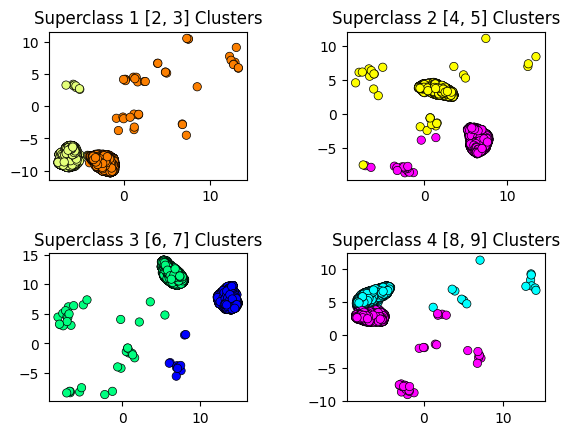

In [243]:
# plotting the rest of the superclass clusters
fig, axs = plt.subplots(2, 2)
axs[0, 0].scatter(class1[:, 0], class1[:, 1],
                  c=labels1,
                  cmap='Wistia',
                  edgecolors='black',
                  linewidths=0.5)
axs[0, 0].set_title("Superclass 1 [2, 3] Clusters")

axs[0, 1].scatter(class2[:, 0], class2[:, 1],
                  c=labels2,
                  cmap='spring',
                  edgecolors='black',
                  linewidths=0.5)
axs[0, 1].set_title("Superclass 2 [4, 5] Clusters")

axs[1, 0].scatter(class3[:, 0], class3[:, 1],
                  c=labels3,
                  cmap='winter',
                  edgecolors='black',
                  linewidths=0.5)
axs[1, 0].set_title("Superclass 3 [6, 7] Clusters")

axs[1, 1].scatter(class4[:, 0], class4[:, 1],
                  c=labels4,
                  cmap='cool',
                  edgecolors='black',
                  linewidths=0.5)
axs[1, 1].set_title("Superclass 4 [8, 9] Clusters")

plt.subplots_adjust(wspace=0.5)
plt.subplots_adjust(hspace=0.5)
plt.show()

The next step is to initialize the training set with the subclass labels obtained.

In [244]:
# initializing subclass labels in trainset list
idx0 = 0
idx1 = 0
idx2 = 0
idx3 = 0
idx4 = 0
idx = 0

for img, sup, sub in trainset_subclass:
  if sup == 0:
    trainset_subclass[idx] = (img, sup, labels0[idx0])
    idx0 = idx0 + 1
  elif sup == 1:
    trainset_subclass[idx] = (img, sup, labels1[idx1])
    idx1 = idx1 + 1
  elif sup == 2:
    trainset_subclass[idx] = (img, sup, labels2[idx2])
    idx2 = idx2 + 1
  elif sup == 3:
    trainset_subclass[idx] = (img, sup, labels3[idx3])
    idx3 = idx3 + 1
  elif sup == 4:
    trainset_subclass[idx] = (img, sup, labels4[idx4])
    idx4 = idx4 + 1
  idx = idx + 1

In [245]:
# rough testing to check subclass pairs in superclass
i = 0
for img, sup, sub in trainset_subclass:
  print(f"index {i}, super_class_label {sup}, sub_class_label {sub}")
  i = i + 1
  if i > 10:
    break

index 0, super_class_label 2, sub_class_label 1
index 1, super_class_label 0, sub_class_label 1
index 2, super_class_label 2, sub_class_label 0
index 3, super_class_label 0, sub_class_label 0
index 4, super_class_label 4, sub_class_label 0
index 5, super_class_label 1, sub_class_label 0
index 6, super_class_label 0, sub_class_label 0
index 7, super_class_label 1, sub_class_label 1
index 8, super_class_label 0, sub_class_label 0
index 9, super_class_label 2, sub_class_label 0
index 10, super_class_label 2, sub_class_label 1


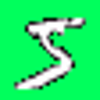

In [246]:
# image at index 0 has super class 2 and subclass 1
T.ToPILImage()(trainset_subclass[0][0]).resize((100,100))

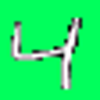

In [247]:
# image at index 2 has super class 2 and subclass 0
T.ToPILImage()(trainset_subclass[2][0]).resize((100,100))

## 3) Retraining CNN using subclass labels and minimizing robust loss

In [248]:
# separating data, superclass labels, and subclass labels
trainset_subclass_data = []
trainset_subclass_sup = []
trainset_subclass_sub = []
supsub_to_digit = {(0,0):0,
                   (0,1):1,
                   (1,0):2,
                   (1,1):3,
                   (2,0):4,
                   (2,1):5,
                   (3,0):6,
                   (3,1):7,
                   (4,0):8,
                   (4,1):9}

for img, sup, sub in trainset_subclass:
  trainset_subclass_data.append(img)
  trainset_subclass_sup.append(sup)
  trainset_subclass_sub.append(supsub_to_digit[(sup, sub)])

print(len(trainset_subclass_data))
print(len(trainset_subclass_sup))
print(len(trainset_subclass_sub))

48004
48004
48004


In [249]:
trainset_subclass_data = torch.stack(trainset_subclass_data)
trainset_subclass_sup = torch.tensor(trainset_subclass_sup)
trainset_subclass_sub = torch.tensor(trainset_subclass_sub)
print(trainset_subclass_data.shape)
print(trainset_subclass_sup.shape)
print(trainset_subclass_sub.shape)

torch.Size([48004, 3, 28, 28])
torch.Size([48004])
torch.Size([48004])


In [250]:
# creating a dataset class that includes subclasses
class SpuCoMNIST_subclass(torch.utils.data.Dataset):
  def __init__(self, data, sup, sub):
    self.data = data
    self.sup = sup
    self.sub = sub
  def __getitem__(self, index):
    return self.data[index], self.sup[index], self.sub[index]
  def __len__(self):
    return len(self.data)

In [251]:
# creating a sampler to ensure each batch has has an equal number images per subclass
from torch.utils.data import Sampler
import random

class BalancedBatchSampler(Sampler):
  def __init__(self, subclass_labels, batch_size):
    self.subclass_labels = subclass_labels
    self.batch_size = batch_size
    self.subclass_indices = {0:[], 1:[], 2:[], 3:[], 4:[],
                             5:[], 6:[], 7:[], 8:[], 9:[]}

    idx = 0
    for sub in self.subclass_labels:
      self.subclass_indices[int(sub)].append(idx)
      idx = idx + 1

    # shuffling indices for each subclass
    for subclass in self.subclass_indices:
      random.shuffle(self.subclass_indices[subclass])

    self.sub_batch_size = batch_size // 10

  def __iter__(self):
    # subclass_iter = {subclass_label:iterable}
    subclass_iter = {i:iter(self.subclass_indices[i]) for i in self.subclass_indices}

    batches = []
    running = True
    while running:
      batch = []
      for subclass in subclass_iter:
        indices = []
        try:
          for i in range(self.sub_batch_size):
            indices.append(next(subclass_iter[subclass]))
        except StopIteration:
          # no more images left in subclass
          running = False
          break
        batch.extend(indices)
      if len(batch) == self.batch_size:
        batches.append(batch)

    # yield batches
    for batch in batches:
      yield batch

  def __len__(self):
    return len(self.subclass_labels) // self.batch_size

In [252]:
# initializing dataset and dataloader
trainset_SpuCo_subclass = SpuCoMNIST_subclass(trainset_subclass_data,
                                              trainset_subclass_sup,
                                              trainset_subclass_sub)
trainset_SpuCo_subclass_loader = DataLoader(
    trainset_SpuCo_subclass,
    batch_sampler=BalancedBatchSampler(trainset_subclass_sub, 70)
)

In [253]:
# retraining model with subclass labels
def train_subclass_balanced():
  num_epoch = 25

  for epoch in range(num_epoch):
    spucoCNN_model.train()
    for i, (inputs, labels, subclass_labels) in enumerate(trainset_SpuCo_subclass_loader):
      optimizer.zero_grad()
      inputs = inputs.to(device)
      labels = labels.to(device)
      subclass_labels = subclass_labels.to(device)

      outputs = spucoCNN_model.forward(inputs)  # ouputs = logits, linear_layer
      predicted_labels = torch.argmax(outputs[0], axis=1)
      accuracy = np.mean(np.array(labels == predicted_labels))

      # computing loss for each subclass
      loss = criterion(outputs[0], labels)
      for sup in range(5):
        outputs_filtered = outputs[0][labels == sup]
        labels_filtered = labels[labels == sup]
        subclass_labels_filtered = subclass_labels[labels == sup]
        for sub in range(2):
          outputs_filtered_sub = outputs_filtered[subclass_labels_filtered == sub]
          labels_filtered_sub = labels_filtered[subclass_labels_filtered == sub]
          if labels_filtered_sub.shape[0] == 0: # subclass not present in batch
            continue
          loss_sub = criterion(outputs_filtered_sub, labels_filtered_sub)
          if loss_sub > loss:
            loss = loss_sub

      # loss = criterion(outputs[0], labels)
      loss.backward()
      optimizer.step()

      if i % 300 == 0:
          print(f"epoch {epoch}, iter {i}, loss: {loss.item()}, accuracy: {accuracy}")

train_subclass_balanced()

epoch 0, iter 0, loss: 0.0016532252775505185, accuracy: 1.0
epoch 0, iter 300, loss: 0.22285862267017365, accuracy: 0.9714285714285714
epoch 0, iter 600, loss: 0.004673320800065994, accuracy: 1.0
epoch 1, iter 0, loss: 0.014169754460453987, accuracy: 1.0
epoch 1, iter 300, loss: 0.22837188839912415, accuracy: 0.9714285714285714
epoch 1, iter 600, loss: 0.004010938573628664, accuracy: 1.0
epoch 2, iter 0, loss: 0.007646474521607161, accuracy: 1.0
epoch 2, iter 300, loss: 0.25075626373291016, accuracy: 0.9714285714285714
epoch 2, iter 600, loss: 0.003291235538199544, accuracy: 1.0
epoch 3, iter 0, loss: 0.0048490241169929504, accuracy: 1.0
epoch 3, iter 300, loss: 0.2727455198764801, accuracy: 0.9714285714285714
epoch 3, iter 600, loss: 0.003932095132768154, accuracy: 1.0
epoch 4, iter 0, loss: 0.004928054753690958, accuracy: 1.0
epoch 4, iter 300, loss: 0.27232927083969116, accuracy: 0.9714285714285714
epoch 4, iter 600, loss: 0.008214903995394707, accuracy: 1.0
epoch 5, iter 0, loss: 0

In [254]:
test_loader = DataLoader(
    testset,
    batch_size=64,
    shuffle=True
)

In [255]:
# evaluating model performance before GDRO
def subclass_test():
  num_batches = 0
  acc_agg = 0
  spucoCNN_model.eval()
  for i, (inputs, labels) in enumerate(test_loader):
    inputs = inputs.to(device)
    labels = labels.to(device)

    outputs = spucoCNN_model.forward(inputs)  # ouputs = logits, linear_layer
    predicted_labels = torch.argmax(outputs[0], axis=1)
    accuracy = np.mean(np.array(labels == predicted_labels))

    if i % 10 == 0:
          print(f"iter {i}, accuracy: {accuracy}")
    num_batches = num_batches + 1
    acc_agg = acc_agg + accuracy

  print(f"final accuracy: {acc_agg / num_batches}")

subclass_test()

iter 0, accuracy: 0.484375
iter 10, accuracy: 0.53125
iter 20, accuracy: 0.53125
iter 30, accuracy: 0.4375
iter 40, accuracy: 0.5625
iter 50, accuracy: 0.421875
iter 60, accuracy: 0.390625
iter 70, accuracy: 0.5625
iter 80, accuracy: 0.515625
iter 90, accuracy: 0.5
iter 100, accuracy: 0.59375
iter 110, accuracy: 0.359375
iter 120, accuracy: 0.515625
iter 130, accuracy: 0.515625
iter 140, accuracy: 0.59375
iter 150, accuracy: 0.515625
final accuracy: 0.5109474522292994


## References:
- No Subclass Left Behind: https://arxiv.org/pdf/2011.12945
- SpuCo MNIST Documentation: https://spuco.readthedocs.io/en/latest/reference/datasets.html#spuco.datasets.spuco_mnist.SpuCoMNIST
- SpuCo QuickStart Notebooks: https://github.com/BigML-CS-UCLA/SpuCo